<a href="https://colab.research.google.com/github/Nick97382000/ML_Projects/blob/main/Lasso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Lasso
The lasso is a linear model that estimates sparse coefficients, it is able to set coefficients exactly to zero; it reduces the number of features upon which the given solution is dependent. The funcion to minimize is:

$$ \frac{1}{2n_{samples}} ||Xw-y||^2_2 +\alpha||w||_1$$

where $||w||_1$ is the $l_1$ norm of the coefficient vector.


### Generate the dataset
We generate a dataset where the number of smaples is lower than the total number of features, leading to an undetermined system. The target y is a linear combination with alternating signs of sinusoidal signals; only the ten lowest out of the 100 freequencies in X are used to generate y.

Text(0.5, 1.0, 'Superposition of sinusoidal signals')

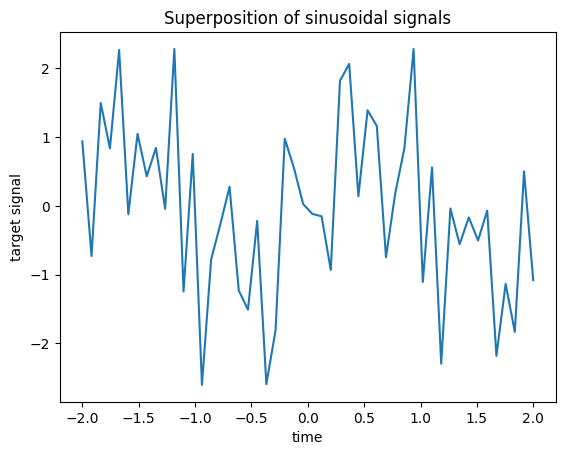

In [16]:
import numpy as np

rng = np.random.RandomState(0)
n_samples, n_features, n_informative = 50, 100, 10
time_step =np.linspace(-2,2,n_samples)

#fill a vetor of n_features elements by random values and sort it
freqs = 2 * np.pi * np.sort(rng.rand(n_features))/0.01
X = np.zeros((n_samples, n_features))

#generate sinusodial output adding random noise in the argument
for i in range(n_features):
  X[:, i] = np.sin(freqs[i]*time_step)

idx = np.arange(n_features)

#evaluate coefficients to generate target
true_coef = (-1) ** idx * np.exp(-idx/10)

#only first 10 observables are used for the target
true_coef[n_informative:] = 0
y = np.dot(X, true_coef)

#A random phase and some Gaussian noise is added to both features and target
for i in range(n_features):
  X[:, i] = np.sin(freqs[i] * time_step + 2 * (rng.random_sample() - 0.5))
  X[:, i]  += 0.2 * rng.normal(0, 1, n_samples)

y += 0.2 * rng.normal(0, 1, n_samples)

import matplotlib.pyplot as plt
plt.plot(time_step, y)
plt.ylabel("target signal")
plt.xlabel("time")
plt.title("Superposition of sinusoidal signals")